# Stacked DiD Version Comparison

This notebook compares four stacked-DiD construction variants for `matched_ihmp_share` and `matched_opt_takeup`.

For each spec it plots three event-study paths separately:

- zeroth stage: outcome is the exposure measure used to define the event;
- first stage: outcome is `ihs(any_opt_hires_correction_aware)`;
- reduced form: outcome is `ihs(y_new_hires_foreign_lag0)`.

Figures are displayed inline when the plotting cells run.

In [16]:
from __future__ import annotations

import copy
import math
import sys
import time
from dataclasses import dataclass
from pathlib import Path

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CODE_ROOT = Path('/home/yk0581/h1bworkers/code')
if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

from company_shift_share.config_loader import get_cfg_section, load_config
from company_shift_share import design_comparison_suite as dcs

plt.rcParams.update({
    'figure.figsize': (8.5, 5.2),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})


In [ ]:
CONFIG_PATH = CODE_ROOT / 'configs' / 'company_shift_share_design_comparison.yaml'
cfg_full = load_config(CONFIG_PATH)
cmp_cfg_base = copy.deepcopy(get_cfg_section(cfg_full, 'design_comparison'))
paths_cfg = get_cfg_section(cfg_full, 'paths')

# Keep notebook output readable. The plotted figures still display inline.
cmp_cfg_base['verbose'] = False
cmp_cfg_base['first_stage_type'] = 'ols_ihs'
cmp_cfg_base['stacked_matching_styles'] = ['matched']

OUT_DIR = Path(str(paths_cfg['out_dir']))
PREPARED_STACKED_PATH = OUT_DIR / 'prepared_panels' / 'stacked_did.parquet'
NOTEBOOK_OUT_DIR = OUT_DIR / 'notebook_stacked_version_comparison'
NOTEBOOK_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional: rebuild a separate early-year prepared panel. This is intentionally
# off by default because it may rebuild WRDS-derived source caches and can take
# a long time. Set both flags to True to run it; outputs are isolated under
# NOTEBOOK_OUT_DIR and do not overwrite the production apr2026 caches.
USE_EARLY_PREPARED_PANEL = False
ALLOW_EXPENSIVE_EARLY_REBUILD = False
# Extra guard: building a source panel before the existing source-cache start
# year requires a WRDS workforce rebuild/requery. Leave this False unless you
# explicitly want the notebook to start that WRDS work.
ALLOW_WRDS_REQUERY_FOR_EARLY_SOURCE = False
EARLY_DATA_MIN_T = 2008
EARLY_DATA_MAX_T = int(cmp_cfg_base.get('data_max_t', 2022))
EARLY_SOURCE_OUT_DIR = NOTEBOOK_OUT_DIR / f'source_cache_{EARLY_DATA_MIN_T}_{EARLY_DATA_MAX_T}'
EARLY_DESIGN_OUT_DIR = NOTEBOOK_OUT_DIR / f'design_comparison_{EARLY_DATA_MIN_T}_{EARLY_DATA_MAX_T}'
EARLY_SOURCE_CONFIG_PATH = NOTEBOOK_OUT_DIR / f'company_shift_share_exposure_event_study_{EARLY_DATA_MIN_T}_{EARLY_DATA_MAX_T}.yaml'
EARLY_COMPARISON_CONFIG_PATH = NOTEBOOK_OUT_DIR / f'company_shift_share_design_comparison_{EARLY_DATA_MIN_T}_{EARLY_DATA_MAX_T}.yaml'
EARLY_PREPARED_STACKED_PATH = EARLY_DESIGN_OUT_DIR / 'prepared_panels' / 'stacked_did.parquet'

# Controls in fixed versions are retained only if their max exposure inside the
# matched stack window is <= this threshold. Edit these before running if you
# want a different operational definition of "low exposure".
CONTROL_EXPOSURE_MAX = {
    # About the lower quartile of positive z_ct_ihmp_share firm-years.
    'ihmp_share': 0.05,
    'opt_takeup': 1.0,
}

VERSION_SPECS = [
    {
        'version': 'v1_current',
        'label': '1. current',
        'current_builder': True,
        'cohort_min_year': 2013,
        'cohort_max_year': 2016,
        'strict_match_cols': [],
        'control_thresholds': None,
    },
    {
        'version': 'v2_fixed',
        'label': '2. fixed',
        'current_builder': False,
        'cohort_min_year': 2013,
        'cohort_max_year': 2016,
        'strict_match_cols': ['naics2'],
        'control_thresholds': CONTROL_EXPOSURE_MAX,
    },
    {
        'version': 'v3_fixed_wide_cohorts',
        'label': '3. fixed + cohorts 2010-2018',
        'current_builder': False,
        'cohort_min_year': 2010,
        'cohort_max_year': 2018,
        'strict_match_cols': ['naics2'],
        'control_thresholds': CONTROL_EXPOSURE_MAX,
    },
    {
        'version': 'v4_fixed_strict_metro',
        'label': '4. fixed + strict metro',
        'current_builder': False,
        'cohort_min_year': 2013,
        'cohort_max_year': 2016,
        'strict_match_cols': ['naics2', 'company_metro_feature'],
        'control_thresholds': CONTROL_EXPOSURE_MAX,
    },
]
VERSION_ORDER = [v['version'] for v in VERSION_SPECS]
VERSION_LABELS = {v['version']: v['label'] for v in VERSION_SPECS}

PANEL_TAG = f'early_{EARLY_DATA_MIN_T}_{EARLY_DATA_MAX_T}' if USE_EARLY_PREPARED_PANEL else 'default'
USE_RESULT_CACHE = True
RESULT_CACHE_PATH = NOTEBOOK_OUT_DIR / f'stacked_version_comparison_coefficients_{PANEL_TAG}.csv'
SUMMARY_CACHE_PATH = NOTEBOOK_OUT_DIR / f'stacked_version_comparison_summary_{PANEL_TAG}.csv'
EVENT_TIMING_CACHE_PATH = NOTEBOOK_OUT_DIR / f'stacked_version_comparison_event_timing_{PANEL_TAG}.csv'

print(f'Config: {CONFIG_PATH}')
print(f'Prepared panel: {EARLY_PREPARED_STACKED_PATH if USE_EARLY_PREPARED_PANEL else PREPARED_STACKED_PATH}')
print(f'Notebook output dir: {NOTEBOOK_OUT_DIR}')


Config: /home/yk0581/h1bworkers/code/configs/company_shift_share_design_comparison.yaml
Prepared panel: /home/yk0581/data/out/company_shift_share_apr2026/design_comparison/prepared_panels/stacked_did.parquet
Notebook output dir: /home/yk0581/data/out/company_shift_share_apr2026/design_comparison/notebook_stacked_version_comparison


## Load Prepared Panel

The notebook first tries to reuse the comparison-suite prepared `stacked_did.parquet`. If it is missing, it prepares the panel from the configured caches.

To allow earlier cohorts in version 3, set `USE_EARLY_PREPARED_PANEL = True` and `ALLOW_EXPENSIVE_EARLY_REBUILD = True` in the config cell above. The rebuild writes isolated source and prepared-panel caches under the notebook output directory. With `EARLY_DATA_MIN_T = 2008` and a 3-year pre-window, 2011 is the earliest cohort that can survive the full-window stack filter; including 2010 cohorts would require source and shift-share data back to 2007.

In [18]:
def parquet_year_range(path: str | Path, *, time_col: str = 't') -> tuple[int | None, int | None]:
    path = Path(path)
    if not path.exists():
        return None, None
    try:
        values = pd.read_parquet(path, columns=[time_col])[time_col]
    except Exception:
        return None, None
    years = pd.to_numeric(values, errors='coerce').dropna()
    if years.empty:
        return None, None
    return int(years.min()), int(years.max())


def early_source_cache_coverage_gaps() -> list[str]:
    source_cfg = load_config(cmp_cfg_base['source_config_path'])
    source_paths = get_cfg_section(source_cfg, 'paths')
    checks = {
        'source analysis panel': source_paths.get('opt_exposure_analysis_panel_out'),
        'source OPT counts': source_paths.get('source_opt_counts_out'),
        'WRDS company-year workforce': source_paths.get('wrds_company_year_workforce_out'),
    }
    gaps: list[str] = []
    for label, path in checks.items():
        year_min, year_max = parquet_year_range(path)
        if year_min is None or year_max is None:
            gaps.append(f'{label}: missing or no parseable t column at {path}')
        elif year_min > int(EARLY_DATA_MIN_T) or year_max < int(EARLY_DATA_MAX_T):
            gaps.append(f'{label}: cache covers {year_min}-{year_max}, requested {EARLY_DATA_MIN_T}-{EARLY_DATA_MAX_T} ({path})')
    return gaps


def write_early_rebuild_configs() -> tuple[dict, Path]:
    source_cfg = load_config(cmp_cfg_base['source_config_path'])
    source_paths = get_cfg_section(source_cfg, 'paths')
    EARLY_SOURCE_OUT_DIR.mkdir(parents=True, exist_ok=True)

    # Redirect only source/workforce/model outputs. Raw input paths stay as in
    # the source config. This avoids overwriting the production apr2026 caches.
    for key in [
        'source_opt_counts_out',
        'school_opt_benchmark_out',
        'opt_exposure_analysis_panel_out',
        'company_features_out',
        'outside_negative_sample_out',
        'wrds_company_year_workforce_out',
        'wrds_workforce_user_ids_out',
        'wrds_workforce_users_out',
        'wrds_workforce_positions_out',
        'wrds_workforce_selected_us_positions_out',
        'wrds_user_profile_origin_out',
        'wrds_school_flows_out',
        'opt_probability_index_out',
    ]:
        if key in source_paths:
            source_paths[key] = str(EARLY_SOURCE_OUT_DIR / Path(str(source_paths[key])).name)
    for key in [
        'wrds_workforce_users_chunk_dir',
        'wrds_workforce_positions_chunk_dir',
        'wrds_workforce_selected_us_positions_chunk_dir',
    ]:
        if key in source_paths:
            source_paths[key] = str(EARLY_SOURCE_OUT_DIR / Path(str(source_paths[key])).name)

    exp_cfg = get_cfg_section(source_cfg, 'exposure_event_study')
    exp_cfg['data_min_t'] = int(EARLY_DATA_MIN_T)
    exp_cfg['data_max_t'] = int(EARLY_DATA_MAX_T)
    exp_cfg['exposure_year_min'] = min(int(exp_cfg.get('exposure_year_min', 2010)), int(EARLY_DATA_MIN_T))
    get_cfg_section(source_cfg, 'revelio_company_features')['feature_year_min'] = min(
        int(get_cfg_section(source_cfg, 'revelio_company_features').get('feature_year_min', 2010)),
        int(EARLY_DATA_MIN_T),
    )
    EARLY_SOURCE_CONFIG_PATH.write_text(yaml.safe_dump(source_cfg, sort_keys=False))

    early_cfg = copy.deepcopy(cfg_full)
    early_paths = get_cfg_section(early_cfg, 'paths')
    early_cmp = get_cfg_section(early_cfg, 'design_comparison')
    early_paths['out_dir'] = str(EARLY_DESIGN_OUT_DIR)
    shift_candidates = [
        Path(str(paths_cfg.get('shift_share_analysis_panel', ''))),
        OUT_DIR / 'prepared_panels' / 'shift_share.parquet',
    ]
    shift_path = next((path for path in shift_candidates if path.exists()), None)
    if shift_path is None:
        raise FileNotFoundError(
            'Early stacked-panel rebuild still needs an existing shift-share exposure panel. '
            'Checked: ' + ', '.join(str(path) for path in shift_candidates)
        )
    early_paths['shift_share_analysis_panel'] = str(shift_path)
    early_cmp['source_config_path'] = str(EARLY_SOURCE_CONFIG_PATH)
    early_cmp['data_min_t'] = int(EARLY_DATA_MIN_T)
    early_cmp['data_max_t'] = int(EARLY_DATA_MAX_T)
    early_cmp['force_rebuild_base'] = True
    early_cmp['trust_existing_base_caches'] = False
    early_cmp['write_prepared_panels'] = True
    early_cmp['verbose'] = True
    EARLY_COMPARISON_CONFIG_PATH.write_text(yaml.safe_dump(early_cfg, sort_keys=False))
    return early_cfg, EARLY_COMPARISON_CONFIG_PATH


def build_early_prepared_panel() -> pd.DataFrame:
    if not ALLOW_EXPENSIVE_EARLY_REBUILD:
        raise RuntimeError(
            'USE_EARLY_PREPARED_PANEL=True was requested, but the early panel does not exist. '
            'Set ALLOW_EXPENSIVE_EARLY_REBUILD=True to rebuild isolated early-year source caches.'
        )
    coverage_gaps = early_source_cache_coverage_gaps()
    if coverage_gaps and not ALLOW_WRDS_REQUERY_FOR_EARLY_SOURCE:
        raise RuntimeError(
            'The existing source-side caches do not cover the requested early-year panel, so rebuilding would start WRDS/source work.\n'
            + '\n'.join(f'- {gap}' for gap in coverage_gaps)
            + '\nSet ALLOW_WRDS_REQUERY_FOR_EARLY_SOURCE=True only if you intentionally want that rebuild/requery.'
        )
    early_cfg, early_config_path = write_early_rebuild_configs()
    early_cmp = get_cfg_section(early_cfg, 'design_comparison')
    store = dcs.ComparisonDataStore(
        cfg=early_cfg,
        config_path=early_config_path,
        force_rebuild_base=True,
        memory_cache=True,
    )
    prepared = dcs.prepare_comparison_panels(store, early_cmp)
    prepared_dir = EARLY_DESIGN_OUT_DIR / 'prepared_panels'
    prepared_dir.mkdir(parents=True, exist_ok=True)
    for name, panel in prepared.items():
        panel.to_parquet(prepared_dir / f'{name}.parquet', index=False)
    panel = prepared['stacked_did']
    print(f'Built and wrote early prepared stacked panel: {len(panel):,} rows x {len(panel.columns):,} cols')
    return panel


def load_stacked_base_panel() -> pd.DataFrame:
    if USE_EARLY_PREPARED_PANEL:
        if EARLY_PREPARED_STACKED_PATH.exists():
            panel = pd.read_parquet(EARLY_PREPARED_STACKED_PATH)
            print(f'Loaded early prepared stacked panel: {len(panel):,} rows x {len(panel.columns):,} cols')
            return panel
        return build_early_prepared_panel()

    if PREPARED_STACKED_PATH.exists():
        panel = pd.read_parquet(PREPARED_STACKED_PATH)
        print(f'Loaded prepared stacked panel: {len(panel):,} rows x {len(panel.columns):,} cols')
        return panel

    print('Prepared panel not found. Building comparison panels from configured caches...')
    store = dcs.ComparisonDataStore(
        cfg=cfg_full,
        config_path=CONFIG_PATH,
        force_rebuild_base=bool(cmp_cfg_base.get('force_rebuild_base', False)),
        memory_cache=True,
    )
    prepared = dcs.prepare_comparison_panels(store, cmp_cfg_base)
    panel = prepared['stacked_did']
    PREPARED_STACKED_PATH.parent.mkdir(parents=True, exist_ok=True)
    panel.to_parquet(PREPARED_STACKED_PATH, index=False)
    print(f'Built and wrote prepared stacked panel: {len(panel):,} rows x {len(panel.columns):,} cols')
    return panel

base_panel = load_stacked_base_panel()
display(base_panel.head())
print('Years:', int(pd.to_numeric(base_panel['t'], errors='coerce').min()), '-', int(pd.to_numeric(base_panel['t'], errors='coerce').max()))
print('Units:', base_panel['c'].nunique())


Loaded prepared stacked panel: 1,795,716 rows x 77 cols


,c,t,bachelors_opt_hires_correction_aware,masters_opt_hires_correction_aware,phd_opt_hires_correction_aware,any_opt_hires_correction_aware,y_cst_lag0,y_cst_foreign_lag0,y_cst_native_lag0,y_cst_foreign_hard_lag0,...,predicted_prob,predicted_index,predicted_class,event_study_sample,preferred_rcid_source,outside_negative_candidate,target_source,firm_size_annual_pre_level,firm_size_annual_pre_n_years,firm_size_annual_pre_growth
0,1946261,2010,0,0,0,0,32.0,2.333333,29.666667,3.0,...,0.692618,0.692618,1.0,1.0,1.0,0.0,preferred_rcid_source,34.0,4,0.080936
1,1946261,2011,0,0,0,0,29.0,4.333333,24.666667,5.0,...,0.692618,0.692618,1.0,1.0,1.0,0.0,preferred_rcid_source,34.0,4,0.080936
2,1946261,2012,0,0,0,0,36.0,5.666667,30.333333,5.0,...,0.692618,0.692618,1.0,1.0,1.0,0.0,preferred_rcid_source,34.0,4,0.080936
3,1946261,2013,0,0,0,0,39.0,6.666667,32.333333,5.0,...,0.692618,0.692618,1.0,1.0,1.0,0.0,preferred_rcid_source,34.0,4,0.080936
4,1946261,2014,0,0,0,0,47.0,6.333333,40.666667,2.0,...,0.692618,0.692618,1.0,1.0,1.0,0.0,preferred_rcid_source,34.0,4,0.080936


Years: 2010 - 2022
Units: 138132


In [19]:
@dataclass(frozen=True)
class ExposureSpec:
    name: str
    col: str


def available_exposure_specs(panel: pd.DataFrame) -> list[ExposureSpec]:
    candidates = [
        ('ihmp_share', dcs._first_present(panel, ['z_ct_ihmp_share', 'z_ct'])),
        ('opt_takeup', dcs._first_present(panel, ['any_opt_hires_correction_aware', 'masters_opt_hires_correction_aware'])),
    ]
    return [ExposureSpec(name, col) for name, col in candidates if col is not None]


def _safe_key_frame(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    if not cols:
        return pd.Series(['__all__'] * len(df), index=df.index)
    parts = []
    for col in cols:
        parts.append(df[col].astype('string').fillna('__MISSING__'))
    out = parts[0]
    for part in parts[1:]:
        out = out + '||' + part
    return out


def build_strict_pair_frame(
    panel: pd.DataFrame,
    treated: pd.DataFrame,
    controls: pd.DataFrame,
    *,
    strict_cols: list[str],
    cmp_cfg: dict,
) -> pd.DataFrame:
    missing = [col for col in strict_cols if col not in panel.columns]
    if missing:
        raise ValueError(f'Missing strict match columns: {missing}')

    if not strict_cols:
        return dcs._build_pair_frame(panel, treated, controls, matching_style='matched', cmp_cfg=cmp_cfg)

    feature_cols = dcs._matching_feature_cols(panel)
    firm_features = panel.drop_duplicates('c').copy()
    firm_features['c_key'] = firm_features['c'].astype(str)
    control_keys = {str(c) for c in controls['c'].dropna().unique()}
    control_features = firm_features.loc[firm_features['c_key'].isin(control_keys)].copy()
    treated_features = treated.dropna(subset=['c', 'g']).assign(c_key=lambda x: x['c'].astype(str)).merge(
        firm_features,
        on='c_key',
        how='left',
        suffixes=('', '_feature'),
    )
    required = ['c', *strict_cols, *feature_cols]
    treated_features = treated_features.dropna(subset=[col for col in required if col in treated_features.columns]).copy()
    control_features = control_features.dropna(subset=[col for col in strict_cols if col in control_features.columns]).copy()
    if treated_features.empty or control_features.empty:
        return pd.DataFrame()

    rows: list[dict[str, object]] = []
    used_controls: set[object] = set()
    control_features['_strict_key'] = _safe_key_frame(control_features, strict_cols)
    treated_features['_strict_key'] = _safe_key_frame(treated_features, strict_cols)

    for strict_key, treated_idx in treated_features.groupby('_strict_key', sort=False).groups.items():
        t_group = treated_features.loc[list(treated_idx)].reset_index(drop=True)
        c_group = control_features.loc[control_features['_strict_key'].eq(strict_key)].reset_index(drop=True)
        c_group = c_group.loc[~c_group['c'].isin(used_controls)].reset_index(drop=True)
        if t_group.empty or c_group.empty:
            continue

        if not feature_cols:
            for _, t_row in t_group.iterrows():
                remaining = c_group.loc[~c_group['c'].isin(used_controls)]
                if remaining.empty:
                    break
                control_c = remaining.iloc[0]['c']
                used_controls.add(control_c)
                rows.append({'pair_id': len(rows), 'treated_c': t_row['c'], 'control_c': control_c})
            continue

        medians = {col: dcs._finite_or_default(pd.to_numeric(c_group[col], errors='coerce').median(), 0.0) for col in feature_cols}
        scales = {col: dcs._finite_or_default(pd.to_numeric(c_group[col], errors='coerce').std(skipna=True), 1.0) for col in feature_cols}
        control_matrix = dcs._matching_matrix(c_group, feature_cols, medians, scales)
        treated_matrix = dcs._matching_matrix(t_group, feature_cols, medians, scales)
        index = dcs._NeighborIndex(c_group, control_matrix)
        dcs._assign_neighbor_batch(
            index,
            t_group,
            treated_matrix,
            list(range(len(t_group))),
            used_controls,
            rows,
            initial_k=int(cmp_cfg.get('stacked_match_nn_initial_k', 25)),
            max_k=int(cmp_cfg.get('stacked_match_nn_max_k', 25)),
        )

    return pd.DataFrame(rows)


def build_threshold_stacked_panel(
    panel: pd.DataFrame,
    pair_df: pd.DataFrame,
    cohort_df: pd.DataFrame,
    *,
    exposure_col: str,
    control_exposure_max: float,
    pre_window: int,
    post_window: int,
) -> pd.DataFrame:
    if panel.empty or pair_df.empty or cohort_df.empty:
        return pd.DataFrame()

    cohort_lookup = cohort_df.dropna(subset=['g']).rename(columns={'c': 'treated_c', 'g': 'treated_g'})
    pair_cohorts = pair_df.merge(cohort_lookup[['treated_c', 'treated_g']], on='treated_c', how='inner')
    if pair_cohorts.empty:
        return pd.DataFrame()

    pair_long = pd.concat(
        [
            pair_cohorts[['pair_id', 'treated_c', 'treated_g']].rename(columns={'treated_c': 'c'}),
            pair_cohorts[['pair_id', 'control_c', 'treated_g']].rename(columns={'control_c': 'c'}),
        ],
        ignore_index=True,
    )
    pair_long['treated'] = [1] * len(pair_cohorts) + [0] * len(pair_cohorts)

    work = panel.merge(pair_long.dropna(subset=['c', 'treated_g']), on='c', how='inner')
    work['t'] = pd.to_numeric(work['t'], errors='coerce')
    work['treated_g'] = pd.to_numeric(work['treated_g'], errors='coerce')
    work = work.loc[work['t'].between(work['treated_g'] - pre_window, work['treated_g'] + post_window)].copy()
    if work.empty:
        return pd.DataFrame()

    window_len = int(pre_window) + int(post_window) + 1
    control = work.loc[work['treated'].eq(0)].copy()
    valid_pairs = set(control.groupby('pair_id')['t'].nunique().loc[lambda s: s.eq(window_len)].index)
    valid_pairs &= set(work.groupby('pair_id')['t'].nunique().loc[lambda s: s.eq(window_len)].index)
    if exposure_col in work.columns:
        nonmissing_exposure_counts = (
            work.loc[pd.to_numeric(work[exposure_col], errors='coerce').notna()]
            .groupby('pair_id')['t']
            .count()
        )
        valid_pairs &= set(nonmissing_exposure_counts.loc[nonmissing_exposure_counts.eq(2 * window_len)].index)

    if np.isfinite(float(control_exposure_max)) and exposure_col in control.columns:
        control_exposure = pd.to_numeric(control[exposure_col], errors='coerce')
        too_high = control.assign(_too_high=control_exposure.gt(float(control_exposure_max))).groupby('pair_id')['_too_high'].any()
        valid_pairs &= set(too_high.loc[~too_high].index)

    if not valid_pairs:
        return pd.DataFrame()

    out = work.loc[work['pair_id'].isin(valid_pairs)].copy()
    out['stack_id'] = out['pair_id'].astype(int)
    out['g'] = out['treated_g'].astype(int)
    out['rel_time'] = out['t'].astype(int) - out['g'].astype(int)
    out['pair_stack_fe'] = out['pair_id'].astype(str) + '__' + out['stack_id'].astype(str)
    out['unit_stack_fe'] = out['c'].astype(str) + '__' + out['stack_id'].astype(str)
    out['year_stack_fe'] = out['t'].astype(int).astype(str) + '__' + out['stack_id'].astype(str)
    out['high_exposure'] = out['treated']
    out['trajectory_name'] = 'comparison'
    return out.sort_values(['stack_id', 'c', 't']).reset_index(drop=True)


In [20]:
def estimate_three_stage_paths(stacked: pd.DataFrame, *, spec: str, exposure_col: str, cmp_cfg: dict) -> pd.DataFrame:
    if stacked.empty:
        return pd.DataFrame()

    work = dcs._ensure_fe_columns(stacked.copy(), cmp_cfg)
    event_times = sorted(int(v) for v in pd.to_numeric(work['rel_time'], errors='coerce').dropna().unique())
    ref_event_time = int(cmp_cfg.get('stacked_ref_event_time', -1))
    term_to_time, term_meta = dcs._stacked_sun_abraham_terms(work, ref_event_time)
    if not term_to_time:
        return pd.DataFrame()

    fe_cols = dcs._stacked_fe_cols(work, cmp_cfg, 'sun_abraham')
    cluster_col = dcs._stacked_cluster_col('sun_abraham', cmp_cfg)

    first_stage_col = dcs._x_col(work)
    foreign_hires_col = 'y_new_hires_foreign_lag0'
    if foreign_hires_col not in work.columns:
        raise ValueError(f'Missing reduced-form outcome: {foreign_hires_col}')

    stages = [
        ('zeroth_stage', 'zeroth_exposure_ct', exposure_col, pd.to_numeric(work[exposure_col], errors='coerce')),
        ('first_stage', 'ihs_any_opt_hires', first_stage_col, np.arcsinh(pd.to_numeric(work[first_stage_col], errors='coerce'))),
        ('reduced_form', 'ihs_foreign_hires', foreign_hires_col, np.arcsinh(pd.to_numeric(work[foreign_hires_col], errors='coerce'))),
    ]

    rows: list[dict[str, object]] = []
    for family, lhs, outcome_col, values in stages:
        work[lhs] = values
        rows.extend(
            dcs._estimate_stacked_sun_abraham_family(
                work,
                lhs=lhs,
                term_to_time=term_to_time,
                term_meta=term_meta,
                event_times=event_times,
                ref_event_time=ref_event_time,
                family=family,
                spec=spec,
                estimator='ols',
                outcome_col=outcome_col,
                cmp_cfg=cmp_cfg,
                fe_cols=fe_cols,
                cluster_col=cluster_col,
            )
        )

    return pd.DataFrame(rows)


def build_stack_for_version(
    panel: pd.DataFrame,
    event_df: pd.DataFrame,
    exposure: ExposureSpec,
    version_spec: dict,
    cmp_cfg: dict,
) -> pd.DataFrame:
    if bool(version_spec['current_builder']):
        return dcs.build_comparison_stacked_panel(panel, event_df, cmp_cfg, matching_style='matched')

    treated = event_df.loc[event_df['treated'].eq(1)].dropna(subset=['g']).copy()
    controls = event_df.loc[event_df['treated'].eq(0), ['c']].copy()
    pair_df = build_strict_pair_frame(
        panel,
        treated,
        controls,
        strict_cols=list(version_spec['strict_match_cols']),
        cmp_cfg=cmp_cfg,
    )
    thresholds = version_spec.get('control_thresholds') or {}
    control_exposure_max = float(thresholds.get(exposure.name, np.inf))
    return build_threshold_stacked_panel(
        panel,
        pair_df,
        treated[['c', 'g']].copy(),
        exposure_col=exposure.col,
        control_exposure_max=control_exposure_max,
        pre_window=int(cmp_cfg.get('stacked_pre_years', 3)),
        post_window=int(cmp_cfg.get('stacked_post_years', 3)),
    )


def run_version_comparison(panel: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    all_rows: list[pd.DataFrame] = []
    summaries: list[dict[str, object]] = []
    exposures = available_exposure_specs(panel)
    print('Exposure specs:', [(e.name, e.col) for e in exposures])

    for version_spec in VERSION_SPECS:
        cmp_cfg = copy.deepcopy(cmp_cfg_base)
        cmp_cfg['stacked_min_cohort_year'] = int(version_spec['cohort_min_year'])
        cmp_cfg['stacked_max_cohort_year'] = int(version_spec['cohort_max_year'])
        label = version_spec['label']
        print(f'\n{label}')

        for exposure in exposures:
            started = time.perf_counter()
            event_df = dcs.detect_largest_jump_events(
                panel,
                exposure_col=exposure.col,
                cohort_min_year=int(version_spec['cohort_min_year']),
                cohort_max_year=int(version_spec['cohort_max_year']),
                min_jump=float(cmp_cfg.get('stacked_min_event_jump', 0.0)),
                jump_quantile=dcs._stacked_event_jump_quantile(cmp_cfg, exposure.name),
            )
            n_events = int(pd.to_numeric(event_df.get('treated', pd.Series(dtype=float)), errors='coerce').fillna(0).sum())
            stacked = build_stack_for_version(panel, event_df, exposure, version_spec, cmp_cfg)
            spec_name = f'matched_{exposure.name}'
            print(f'  {spec_name}: detected={n_events:,}; stacked={len(stacked):,} rows; stacks={stacked["stack_id"].nunique() if not stacked.empty else 0:,}')

            summaries.append({
                'version': version_spec['version'],
                'version_label': label,
                'spec': spec_name,
                'exposure_col': exposure.col,
                'cohort_min_year': int(version_spec['cohort_min_year']),
                'cohort_max_year': int(version_spec['cohort_max_year']),
                'strict_match_cols': '+'.join(version_spec['strict_match_cols']),
                'control_exposure_max': (version_spec.get('control_thresholds') or {}).get(exposure.name, np.nan),
                'detected_events': n_events,
                'stacked_rows': int(len(stacked)),
                'n_stacks': int(stacked['stack_id'].nunique()) if not stacked.empty else 0,
                'elapsed_seconds': round(time.perf_counter() - started, 3),
            })

            coef = estimate_three_stage_paths(stacked, spec=spec_name, exposure_col=exposure.col, cmp_cfg=cmp_cfg)
            if not coef.empty:
                coef['version'] = version_spec['version']
                coef['version_label'] = label
                coef['exposure_col'] = exposure.col
                all_rows.append(coef)

    coef_df = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
    summary_df = pd.DataFrame(summaries)
    coef_df.to_csv(RESULT_CACHE_PATH, index=False)
    summary_df.to_csv(SUMMARY_CACHE_PATH, index=False)
    print(f'\nWrote coefficients: {RESULT_CACHE_PATH}')
    print(f'Wrote summary: {SUMMARY_CACHE_PATH}')
    return coef_df, summary_df


## Estimate Or Load Results

In [21]:
if USE_RESULT_CACHE and RESULT_CACHE_PATH.exists() and SUMMARY_CACHE_PATH.exists():
    coef_df = pd.read_csv(RESULT_CACHE_PATH)
    summary_df = pd.read_csv(SUMMARY_CACHE_PATH)
    print(f'Loaded cached coefficients: {len(coef_df):,} rows')
else:
    coef_df, summary_df = run_version_comparison(base_panel)

display(summary_df)
display(coef_df.head())


Exposure specs: [('ihmp_share', 'z_ct_ihmp_share'), ('opt_takeup', 'any_opt_hires_correction_aware')]

1. current
  matched_ihmp_share: detected=18,563; stacked=151,760 rows; stacks=10,840
  matched_opt_takeup: detected=49,575; stacked=436,604 rows; stacks=31,186

2. fixed
  matched_ihmp_share: detected=18,563; stacked=140,448 rows; stacks=10,032
  matched_opt_takeup: detected=49,575; stacked=492,450 rows; stacks=35,175

3. fixed + cohorts 2010-2018
  matched_ihmp_share: detected=18,572; stacked=122,752 rows; stacks=8,768
  matched_opt_takeup: detected=72,081; stacked=465,612 rows; stacks=33,258

4. fixed + strict metro
  matched_ihmp_share: detected=18,563; stacked=211,554 rows; stacks=15,111
  matched_opt_takeup: detected=49,575; stacked=599,410 rows; stacks=42,815

Wrote coefficients: /home/yk0581/data/out/company_shift_share_apr2026/design_comparison/notebook_stacked_version_comparison/stacked_version_comparison_coefficients_default.csv
Wrote summary: /home/yk0581/data/out/company_

,version,version_label,spec,exposure_col,cohort_min_year,cohort_max_year,strict_match_cols,control_exposure_max,detected_events,stacked_rows,n_stacks,elapsed_seconds
0,v1_current,1. current,matched_ihmp_share,z_ct_ihmp_share,2013,2016,,NaN,18563,151760,10840,17.092
1,v1_current,1. current,matched_opt_takeup,any_opt_hires_correction_aware,2013,2016,,NaN,49575,436604,31186,31.593
2,v2_fixed,2. fixed,matched_ihmp_share,z_ct_ihmp_share,2013,2016,naics2,0.001,18563,140448,10032,11.594
3,v2_fixed,2. fixed,matched_opt_takeup,any_opt_hires_correction_aware,2013,2016,naics2,1.000,49575,492450,35175,22.645
4,v3_fixed_wide_cohorts,3. fixed + cohorts 2010-2018,matched_ihmp_share,z_ct_ihmp_share,2010,2018,naics2,0.001,18572,122752,8768,11.578
5,v3_fixed_wide_cohorts,3. fixed + cohorts 2010-2018,matched_opt_takeup,any_opt_hires_correction_aware,2010,2018,naics2,1.000,72081,465612,33258,44.827
6,v4_fixed_strict_metro,4. fixed + strict metro,matched_ihmp_share,z_ct_ihmp_share,2013,2016,naics2+company_metro_feature,0.001,18563,211554,15111,67.355
7,v4_fixed_strict_metro,4. fixed + strict metro,matched_opt_takeup,any_opt_hires_correction_aware,2013,2016,naics2+company_metro_feature,1.000,49575,599410,42815,131.671


,family,design,spec,estimator,outcome_col,coef,se,f_stat,n_obs,n_units,rel_time,fe_cols,sa_aggregation,n_treatment_cohorts,is_reference,version,version_label,exposure_col
0,zeroth_stage,stacked_did,matched_ihmp_share,ols,z_ct_ihmp_share,-0.010242,0.000282,1319.605347,83152.0,11882.0,-3,c+t,cohort_weighted,4,NaN,v1_current,1. current,z_ct_ihmp_share
1,zeroth_stage,stacked_did,matched_ihmp_share,ols,z_ct_ihmp_share,-0.001446,0.000247,34.235275,83152.0,11882.0,-2,c+t,cohort_weighted,4,NaN,v1_current,1. current,z_ct_ihmp_share
2,zeroth_stage,stacked_did,matched_ihmp_share,ols,z_ct_ihmp_share,0.046958,0.000398,13947.851312,83152.0,11882.0,0,c+t,cohort_weighted,4,NaN,v1_current,1. current,z_ct_ihmp_share
3,zeroth_stage,stacked_did,matched_ihmp_share,ols,z_ct_ihmp_share,0.050089,0.000455,12135.132452,83152.0,11882.0,1,c+t,cohort_weighted,4,NaN,v1_current,1. current,z_ct_ihmp_share
4,zeroth_stage,stacked_did,matched_ihmp_share,ols,z_ct_ihmp_share,0.055538,0.000500,12350.268555,83152.0,11882.0,2,c+t,cohort_weighted,4,NaN,v1_current,1. current,z_ct_ihmp_share


## Treated Event Timing

The histogram below shows the cohort year `g` distribution for treated events that survive each version's matching and control filters. Counts are therefore counts of included matched stacks, not just initially detected events.

Wrote event timing rows: /home/yk0581/data/out/company_shift_share_apr2026/design_comparison/notebook_stacked_version_comparison/stacked_version_comparison_event_timing_default.csv


,sample,version,version_label,spec,event_year,count
0,detected,v1_current,1. current,matched_ihmp_share,2013,4726
1,detected,v1_current,1. current,matched_ihmp_share,2014,2737
2,detected,v1_current,1. current,matched_ihmp_share,2015,5309
3,detected,v1_current,1. current,matched_ihmp_share,2016,5791
4,included_matched_stacks,v1_current,1. current,matched_ihmp_share,2013,2908


/home/yk0581/data/out/company_shift_share_apr2026/design_comparison/notebook_stacked_version_comparison/matched_ihmp_share_treated_event_timing_included_matched_stacks.png


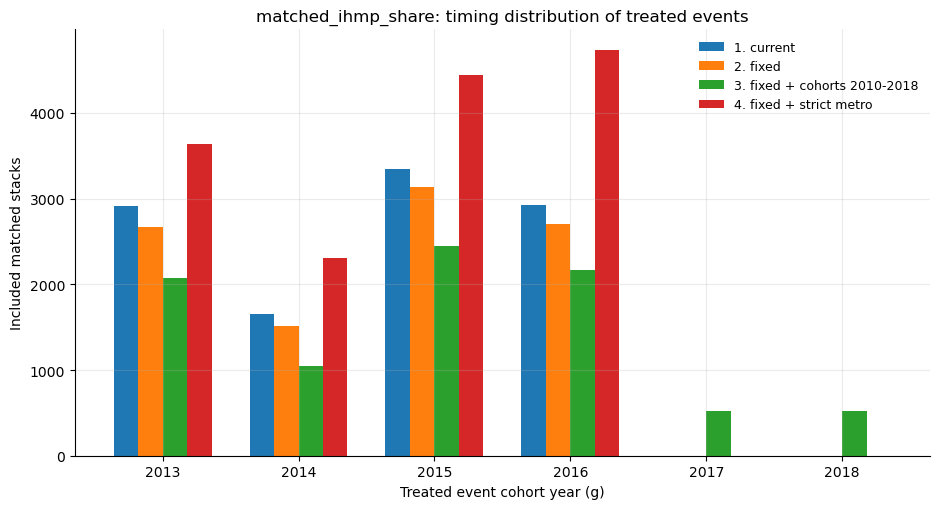

/home/yk0581/data/out/company_shift_share_apr2026/design_comparison/notebook_stacked_version_comparison/matched_opt_takeup_treated_event_timing_included_matched_stacks.png


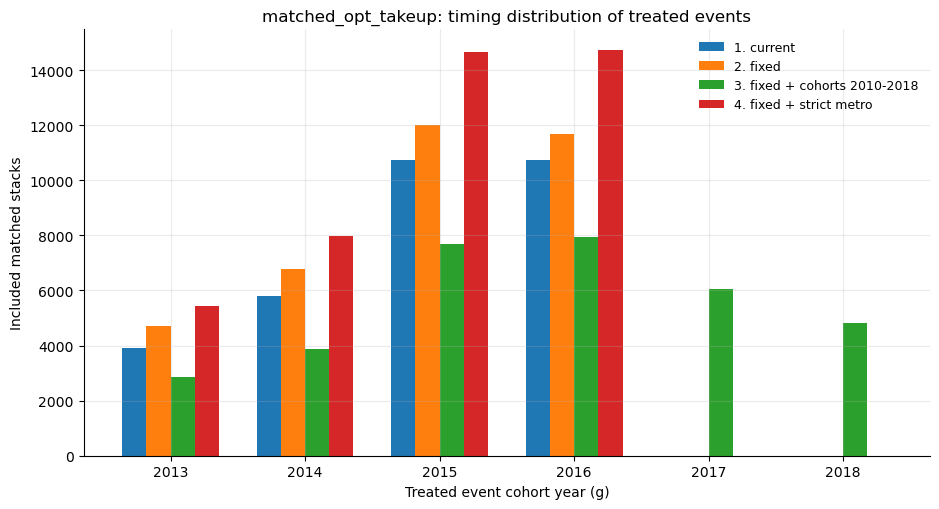

In [22]:
def collect_included_event_timing(panel: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    exposures = available_exposure_specs(panel)

    for version_spec in VERSION_SPECS:
        cmp_cfg = copy.deepcopy(cmp_cfg_base)
        cmp_cfg['stacked_min_cohort_year'] = int(version_spec['cohort_min_year'])
        cmp_cfg['stacked_max_cohort_year'] = int(version_spec['cohort_max_year'])

        for exposure in exposures:
            event_df = dcs.detect_largest_jump_events(
                panel,
                exposure_col=exposure.col,
                cohort_min_year=int(version_spec['cohort_min_year']),
                cohort_max_year=int(version_spec['cohort_max_year']),
                min_jump=float(cmp_cfg.get('stacked_min_event_jump', 0.0)),
                jump_quantile=dcs._stacked_event_jump_quantile(cmp_cfg, exposure.name),
            )
            detected = event_df.loc[event_df['treated'].eq(1), ['c', 'g']].dropna(subset=['g']).copy()
            stacked = build_stack_for_version(panel, event_df, exposure, version_spec, cmp_cfg)
            included = (
                stacked.loc[stacked['treated'].eq(1), ['stack_id', 'c', 'g']]
                .drop_duplicates(['stack_id'])
                .dropna(subset=['g'])
                .copy()
            ) if not stacked.empty else pd.DataFrame(columns=['stack_id', 'c', 'g'])

            detected['g'] = pd.to_numeric(detected['g'], errors='coerce').astype('Int64')
            included['g'] = pd.to_numeric(included['g'], errors='coerce').astype('Int64')

            for g, n in detected.dropna(subset=['g']).groupby('g').size().items():
                rows.append({
                    'sample': 'detected',
                    'version': version_spec['version'],
                    'version_label': version_spec['label'],
                    'spec': f'matched_{exposure.name}',
                    'event_year': int(g),
                    'count': int(n),
                })
            for g, n in included.dropna(subset=['g']).groupby('g').size().items():
                rows.append({
                    'sample': 'included_matched_stacks',
                    'version': version_spec['version'],
                    'version_label': version_spec['label'],
                    'spec': f'matched_{exposure.name}',
                    'event_year': int(g),
                    'count': int(n),
                })

    return pd.DataFrame(rows)


if USE_RESULT_CACHE and EVENT_TIMING_CACHE_PATH.exists():
    event_timing_df = pd.read_csv(EVENT_TIMING_CACHE_PATH)
    print(f'Loaded cached event timing rows: {len(event_timing_df):,}')
else:
    event_timing_df = collect_included_event_timing(base_panel)
    event_timing_df.to_csv(EVENT_TIMING_CACHE_PATH, index=False)
    print(f'Wrote event timing rows: {EVENT_TIMING_CACHE_PATH}')

display(event_timing_df.head())


def plot_event_timing_histograms(event_timing_df: pd.DataFrame, *, sample: str = 'included_matched_stacks') -> None:
    work = event_timing_df.loc[event_timing_df['sample'].eq(sample)].copy()
    if work.empty:
        print(f'No event timing rows for sample={sample}')
        return
    work['event_year'] = pd.to_numeric(work['event_year'], errors='coerce').astype('Int64')
    work['count'] = pd.to_numeric(work['count'], errors='coerce').fillna(0)

    for spec in ['matched_ihmp_share', 'matched_opt_takeup']:
        spec_df = work.loc[work['spec'].eq(spec)].copy()
        if spec_df.empty:
            continue
        years = sorted(int(v) for v in spec_df['event_year'].dropna().unique())
        x = np.arange(len(years), dtype=float)
        width = min(0.18, 0.8 / max(1, len(VERSION_ORDER)))

        fig, ax = plt.subplots(figsize=(9.5, 5.2))
        for idx, version in enumerate(VERSION_ORDER):
            group = spec_df.loc[spec_df['version'].eq(version)].set_index('event_year')
            counts = [float(group['count'].get(year, 0.0)) for year in years]
            offset = (idx - (len(VERSION_ORDER) - 1) / 2) * width
            ax.bar(x + offset, counts, width=width, label=VERSION_LABELS.get(version, version))

        ax.set_xticks(x)
        ax.set_xticklabels([str(year) for year in years])
        ax.set_xlabel('Treated event cohort year (g)')
        ax.set_ylabel('Included matched stacks')
        ax.set_title(f'{spec}: timing distribution of treated events')
        ax.legend(frameon=False, fontsize=9)
        fig.tight_layout()
        path = NOTEBOOK_OUT_DIR / f'{spec}_treated_event_timing_{sample}.png'
        fig.savefig(path, dpi=220, bbox_inches='tight')
        print(path)
        plt.show()


plot_event_timing_histograms(event_timing_df, sample='included_matched_stacks')


/home/yk0581/data/out/company_shift_share_apr2026/design_comparison/notebook_stacked_version_comparison/matched_ihmp_share_zeroth_stage.png


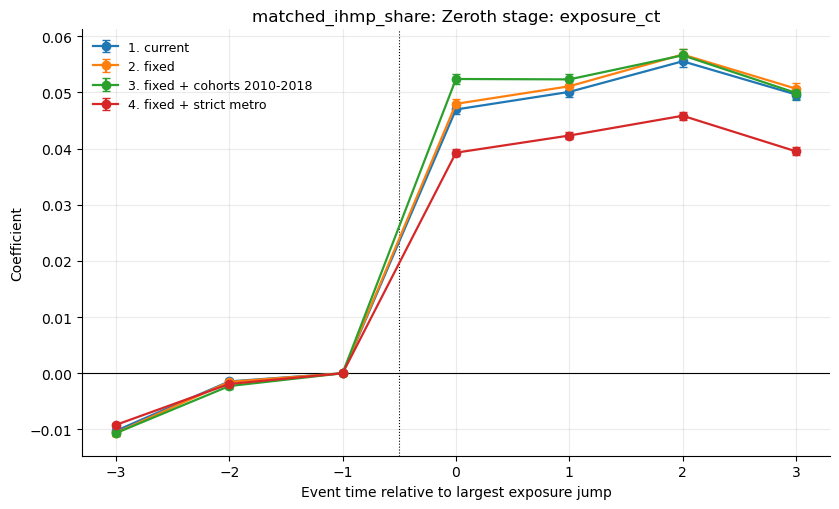

/home/yk0581/data/out/company_shift_share_apr2026/design_comparison/notebook_stacked_version_comparison/matched_ihmp_share_first_stage.png


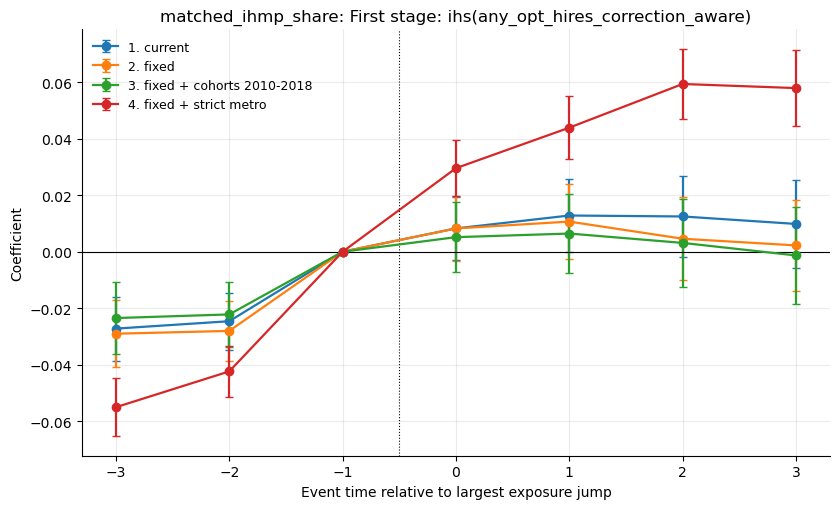

/home/yk0581/data/out/company_shift_share_apr2026/design_comparison/notebook_stacked_version_comparison/matched_ihmp_share_reduced_form.png


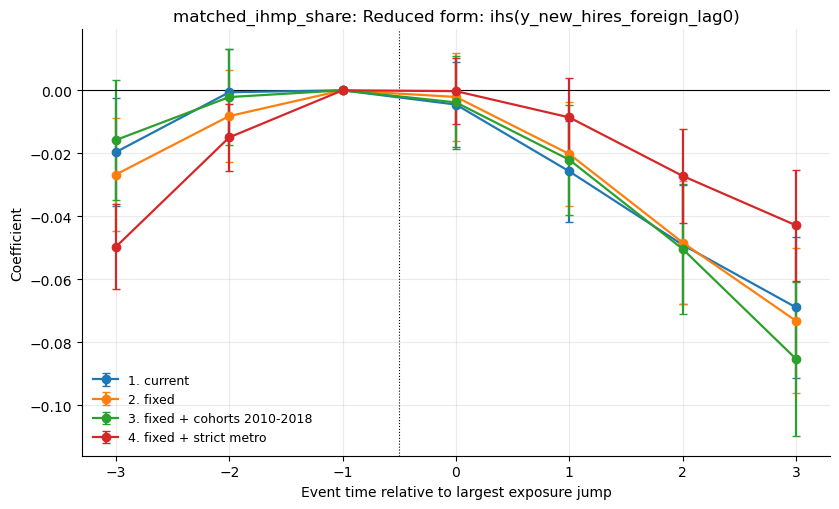

/home/yk0581/data/out/company_shift_share_apr2026/design_comparison/notebook_stacked_version_comparison/matched_opt_takeup_zeroth_stage.png


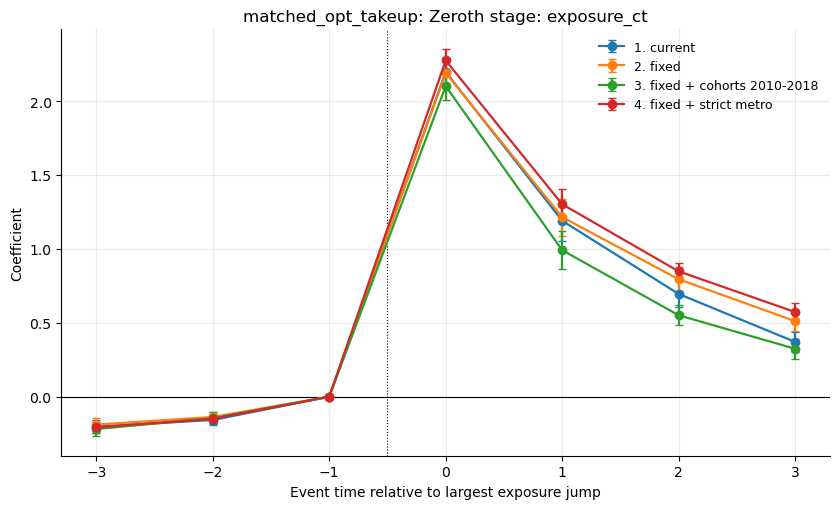

/home/yk0581/data/out/company_shift_share_apr2026/design_comparison/notebook_stacked_version_comparison/matched_opt_takeup_first_stage.png


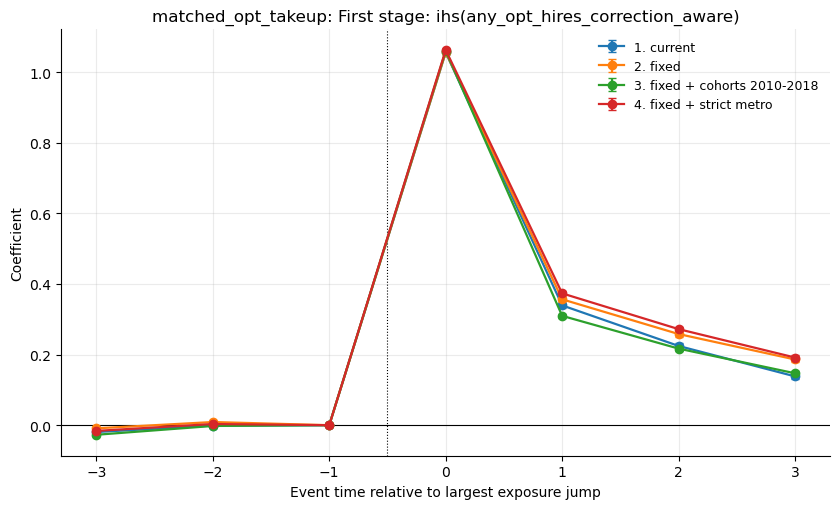

/home/yk0581/data/out/company_shift_share_apr2026/design_comparison/notebook_stacked_version_comparison/matched_opt_takeup_reduced_form.png


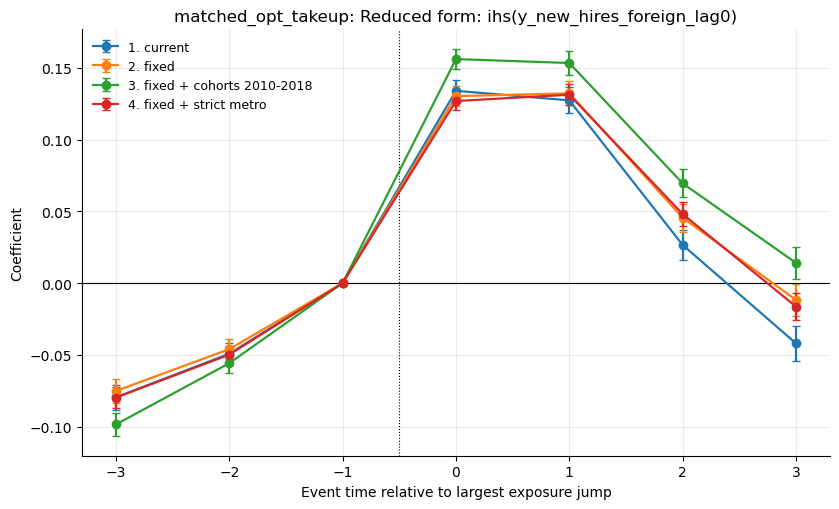

In [23]:
STAGE_LABELS = {
    'zeroth_stage': 'Zeroth stage: exposure_ct',
    'first_stage': 'First stage: ihs(any_opt_hires_correction_aware)',
    'reduced_form': 'Reduced form: ihs(y_new_hires_foreign_lag0)',
}

VERSION_ORDER = [v['version'] for v in VERSION_SPECS]
VERSION_LABELS = {v['version']: v['label'] for v in VERSION_SPECS}


def plot_stage_path(coef_df: pd.DataFrame, *, spec: str, family: str, save: bool = True) -> None:
    work = coef_df.loc[(coef_df['spec'].eq(spec)) & (coef_df['family'].eq(family))].copy()
    if work.empty:
        print(f'No rows for {spec} / {family}')
        return
    work['rel_time'] = pd.to_numeric(work['rel_time'], errors='coerce')
    work['coef'] = pd.to_numeric(work['coef'], errors='coerce')
    work['se'] = pd.to_numeric(work['se'], errors='coerce')
    work = work.dropna(subset=['rel_time', 'coef']).sort_values(['version', 'rel_time'])

    fig, ax = plt.subplots()
    for version in VERSION_ORDER:
        group = work.loc[work['version'].eq(version)].copy()
        if group.empty:
            continue
        yerr = 1.96 * group['se'].fillna(0.0)
        ax.errorbar(
            group['rel_time'],
            group['coef'],
            yerr=yerr,
            marker='o',
            linewidth=1.6,
            capsize=3,
            label=VERSION_LABELS.get(version, version),
        )

    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(-0.5, color='black', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Event time relative to largest exposure jump')
    ax.set_ylabel('Coefficient')
    ax.set_title(f'{spec}: {STAGE_LABELS.get(family, family)}')
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()

    if save:
        path = NOTEBOOK_OUT_DIR / f'{spec}_{family}.png'
        fig.savefig(path, dpi=220, bbox_inches='tight')
        print(path)
    plt.show()


for spec in ['matched_ihmp_share', 'matched_opt_takeup']:
    for family in ['zeroth_stage', 'first_stage', 'reduced_form']:
        plot_stage_path(coef_df, spec=spec, family=family)
